In [253]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import os
import seaborn as sns
from sklearn.model_selection import train_test_split

In [254]:
class LinearRegressionL2:
    def __init__(self, learning_rate=0.01, n_iters=10, l2_penalty=0.01):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.l2_penalty = l2_penalty
        self.weights = None
        self.bias = None
    
    def compute_cost(self, X, y):
        n_samples = X.shape[0]
        predictions = np.dot(X, self.weights) + self.bias
        cost = (1/(2*n_samples)) * np.sum((predictions - y)**2) 
        l2_cost = (self.l2_penalty / (2 * n_samples)) * np.sum(self.weights**2)  # L2 regularization term
        total_cost = cost + l2_cost
        return total_cost

    def gradient_descent(self, X, y):
        n_samples, n_features = X.shape
        predictions = np.dot(X, self.weights) + self.bias
        dw = (1/n_samples) * np.dot(X.T, (predictions - y)) + (self.l2_penalty / n_samples) * self.weights  # Gradient with L2 term
        db = (1/n_samples) * np.sum(predictions - y)
        return dw, db

    def train(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for i in range(self.n_iters):
            dw, db = self.gradient_descent(X, y)
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            if i % 50 == 0:
                cost = self.compute_cost(X, y)
                print(f'Iteration {i} --- Cost: {cost:.4f}')
    
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias
    
    def evaluate(self, X, y):
        predictions = self.predict(X)
        mse = np.mean((predictions - y) ** 2)
        return mse
    
    def get_line_of_best_fit(self):
        return self.weights, self.bias

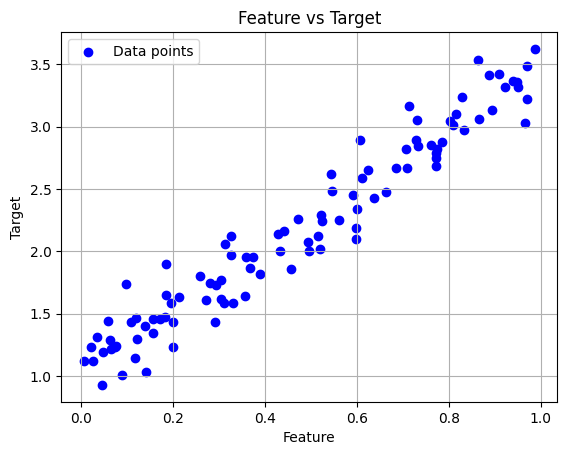

In [255]:
n_samples = 100
np.random.seed(42)
X = np.random.rand(n_samples, 1)
coefficients = np.array([2.5])
intercept = 1.0  # Intercept

noise = np.random.randn(n_samples) * 0.2  
y = np.dot(X, coefficients) + intercept + noise

plt.scatter(X[:, 0], y, color='blue', label="Data points")
plt.title('Feature vs Target')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.legend()
plt.grid(True)
plt.show()

In [256]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

In [257]:
model = LinearRegressionL2(learning_rate=0.1, n_iters=600, l2_penalty=0.1)
model.train(X_train, y_train)

Iteration 0 --- Cost: 2.0235
Iteration 50 --- Cost: 0.0676
Iteration 100 --- Cost: 0.0440
Iteration 150 --- Cost: 0.0322
Iteration 200 --- Cost: 0.0263
Iteration 250 --- Cost: 0.0234
Iteration 300 --- Cost: 0.0220
Iteration 350 --- Cost: 0.0213
Iteration 400 --- Cost: 0.0209
Iteration 450 --- Cost: 0.0207
Iteration 500 --- Cost: 0.0206
Iteration 550 --- Cost: 0.0206


In [258]:
weights, bias = model.get_line_of_best_fit()
print("Weights:", weights)
print("Bias:", bias)

Weights: [2.36221547]
Bias: 1.056288970036867


In [259]:
mse = model.evaluate(X_test, y_test)
print(f'Mean Squared Error: {mse:.4f}')

Mean Squared Error: 0.0258


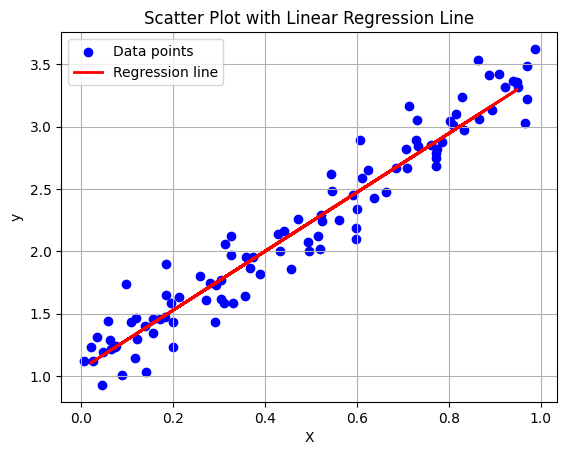

In [260]:
y_pred = model.predict(X_test)

plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X_test, y_pred, color='red', label='Regression line', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Scatter Plot with Linear Regression Line')
plt.legend()
plt.grid(True)
plt.show()